In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification
import zipfile
import pandas as pd

In [14]:
with zipfile.ZipFile('breast+cancer+wisconsin+diagnostic.zip', 'r') as zip_ref:
    file_list = zip_ref.namelist()
    print("Files in zip:", file_list)


    data_file = 'wdbc.data'
    print(f"\nReading file: {data_file}")

    with zip_ref.open(data_file) as f:
        columns = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(30)]
        df = pd.read_csv(f, header=None, names=columns)

        print("\nDataset shape:", df.shape)
        print("First 3 rows:")
        print(df.head(3))
        print("\nColumn names preview:")
        print(df.columns[:5].tolist(), "...")
        print("\n" + "="*60)




Files in zip: ['wdbc.data', 'wdbc.names']

Reading file: wdbc.data

Dataset shape: (569, 32)
First 3 rows:
         id diagnosis  feature_0  feature_1  feature_2  feature_3  feature_4  \
0    842302         M      17.99      10.38      122.8     1001.0    0.11840   
1    842517         M      20.57      17.77      132.9     1326.0    0.08474   
2  84300903         M      19.69      21.25      130.0     1203.0    0.10960   

   feature_5  feature_6  feature_7  ...  feature_20  feature_21  feature_22  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33       184.6   
1    0.07864     0.0869    0.07017  ...       24.99       23.41       158.8   
2    0.15990     0.1974    0.12790  ...       23.57       25.53       152.5   

   feature_23  feature_24  feature_25  feature_26  feature_27  feature_28  \
0      2019.0      0.1622      0.6656      0.7119      0.2654      0.4601   
1      1956.0      0.1238      0.1866      0.2416      0.1860      0.2750   
2      1709.0      0.144

In [9]:
print("\nProcessing data...")
df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})  # Convert M/B to 0/1
X = df.drop(['id', 'diagnosis'], axis=1)  # Features
y = df['diagnosis']
print("\n Data processed: X.shape =", X.shape, "y.shape =", y.shape)

print("TOP 5 FEATURES (LARGEST MEAN DIFFERENCE)")
print("="*60)


Processing data...

 Data processed: X.shape = (569, 30) y.shape = (569,)
TOP 5 FEATURES (LARGEST MEAN DIFFERENCE)


In [10]:
mean_diffs = []
for feature in X.columns:
    mean_mal = X[y == 0][feature].mean()
    mean_ben = X[y == 1][feature].mean()
    diff = abs(mean_mal - mean_ben)
    mean_diffs.append((feature, diff))

# Sort and get top 5
mean_diffs.sort(key=lambda x: x[1], reverse=True)
top5_features = mean_diffs[:5]
print("Top 5 features:")
for i, (feat, diff) in enumerate(top5_features, 1):
    print(f"{i}. {feat}: {diff:.4f}")

Top 5 features:
1. feature_23: 863.3869
2. feature_3: 515.5862
3. feature_22: 54.3644
4. feature_13: 51.5373
5. feature_2: 37.2900


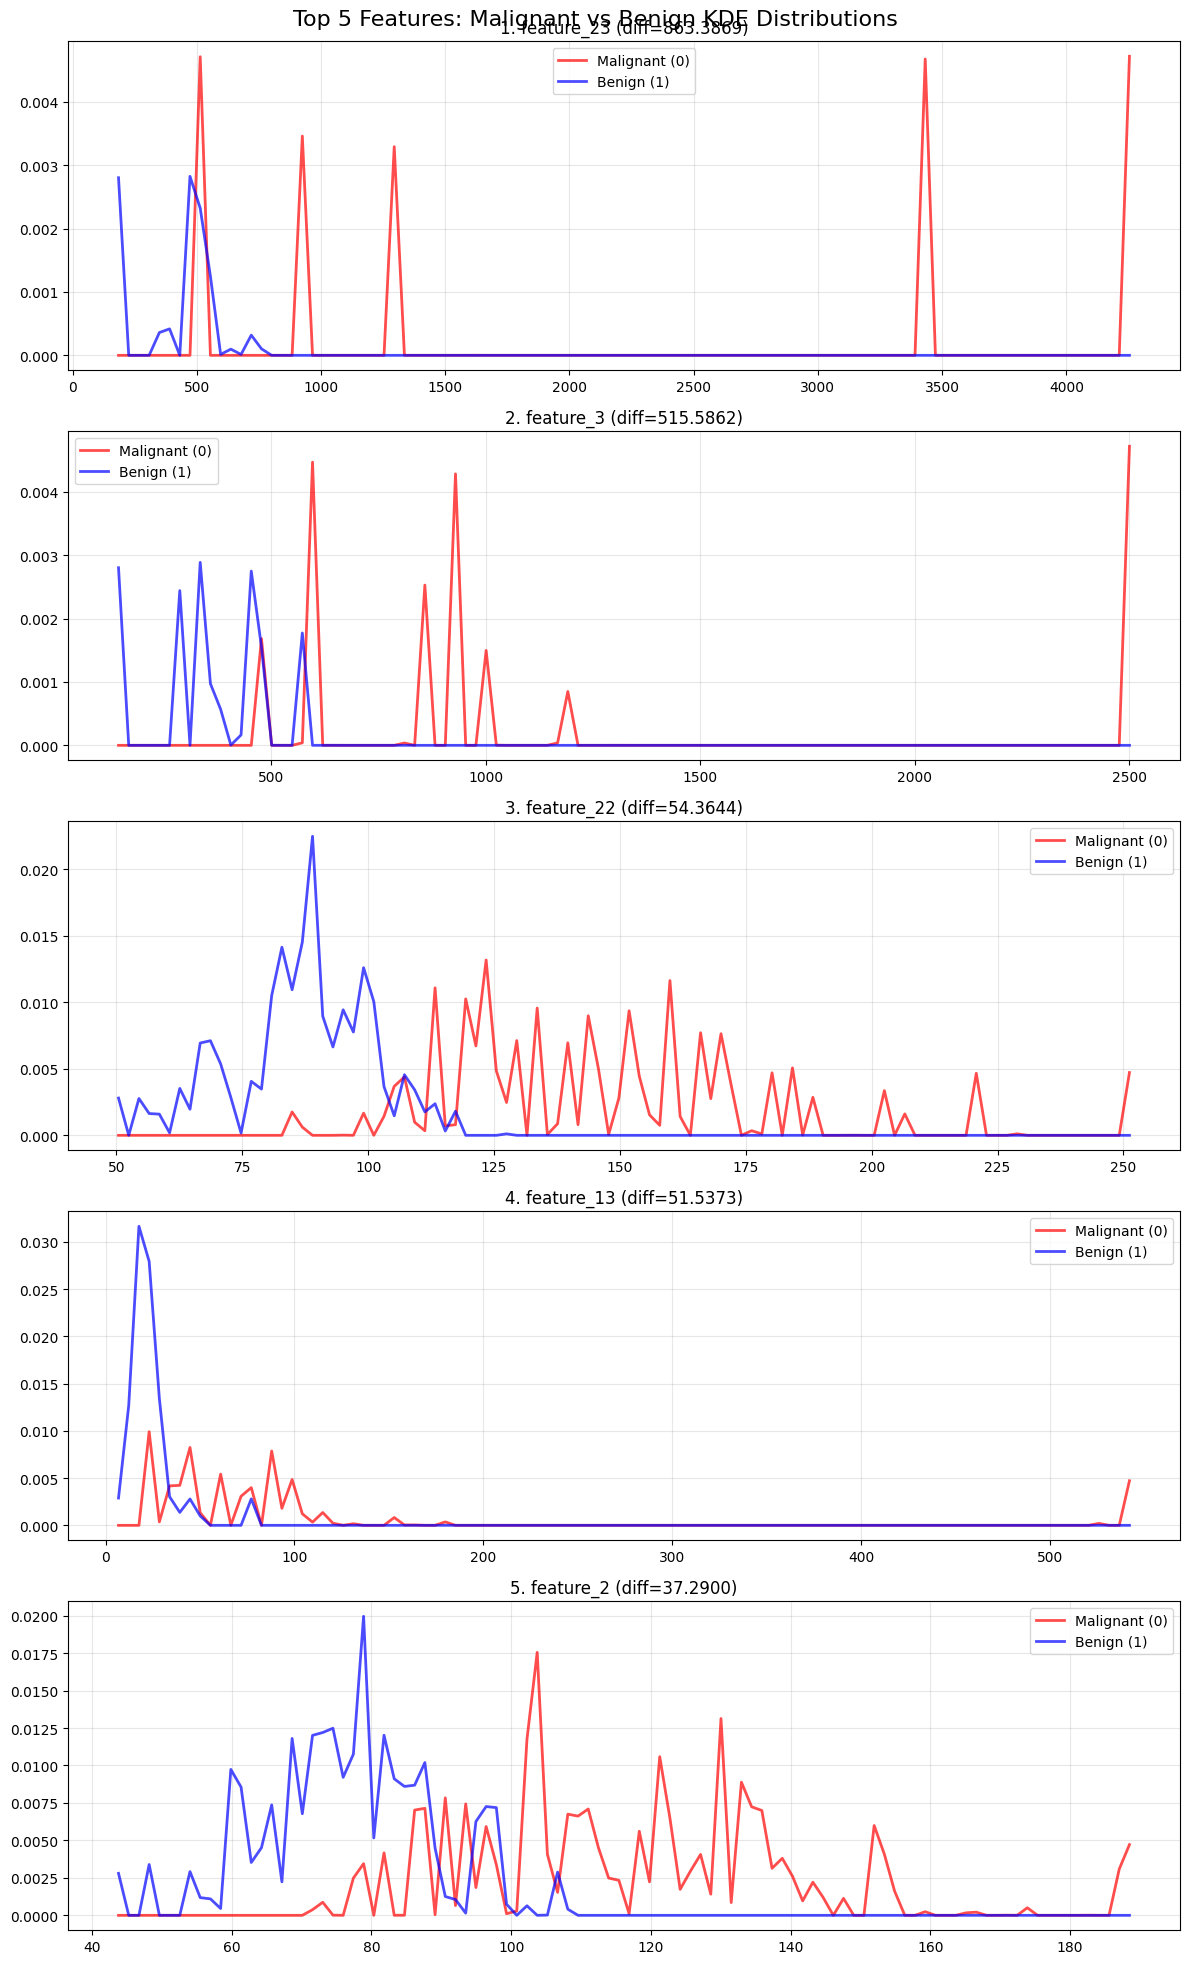


✅ KDE plots saved as 'top5_kde_plots.png'


In [21]:

fig, axes = plt.subplots(5, 1, figsize=(12, 20))
fig.suptitle('Top 5 Features: Malignant vs Benign KDE Distributions', fontsize=16)

for i, (feature, diff) in enumerate(top5_features):
    ax = axes[i]

    # Get data for each class
    mal_data = X[y == 0][feature].values
    ben_data = X[y == 1][feature].values

    # Manual KDE using Gaussian kernel (no scipy)
    x = np.linspace(min(np.r_[mal_data, ben_data]),
                    max(np.r_[mal_data, ben_data]), 100)

    # Malignant KDE
    mal_kde = np.mean([np.exp(-0.5 * ((x - point)/0.15)**2)
                      for point in mal_data], axis=0)
    ax.plot(x, mal_kde, 'r-', linewidth=2, label='Malignant (0)', alpha=0.7)

    # Benign KDE
    ben_kde = np.mean([np.exp(-0.5 * ((x - point)/0.15)**2)
                      for point in ben_data], axis=0)
    ax.plot(x, ben_kde, 'b-', linewidth=2, label='Benign (1)', alpha=0.7)

    ax.set_title(f'{i+1}. {feature} (diff={diff:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('top5_kde_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ KDE plots saved as 'top5_kde_plots.png'")

In [16]:

print("SVM Hard-Margin Mathematical Derivation")
print("="*50)

# (1) PRIMAL FORMULATION
print("\n1. PRIMAL PROBLEM")
print("minimize   1/2 ||w||²")
print("subject to yi(w·xi + b) ≥ 1  ∀i")
print("\nWhere:")
print("• w = weight vector (normal to hyperplane)")
print("• b = bias term")
print("• Margin = 2/||w|| (distance between support hyperplanes)")

print("\n2. DUAL FORM")
print("maximize   Σαᵢ - 1/2 Σᵢⱼ αᵢαⱼ yᵢyⱼ (xᵢ·xⱼ)")
print("subject to Σαᵢyᵢ = 0,  αᵢ ≥ 0")
print("\nKey insight: Only depends on pairwise distances!")

SVM Hard-Margin Mathematical Derivation

1. PRIMAL PROBLEM
minimize   1/2 ||w||²
subject to yi(w·xi + b) ≥ 1  ∀i

Where:
• w = weight vector (normal to hyperplane)
• b = bias term
• Margin = 2/||w|| (distance between support hyperplanes)

2. DUAL FORM
maximize   Σαᵢ - 1/2 Σᵢⱼ αᵢαⱼ yᵢyⱼ (xᵢ·xⱼ)
subject to Σαᵢyᵢ = 0,  αᵢ ≥ 0

Key insight: Only depends on pairwise distances!


BLOCK 1: SVM HYPERPLANE GEOMETRY


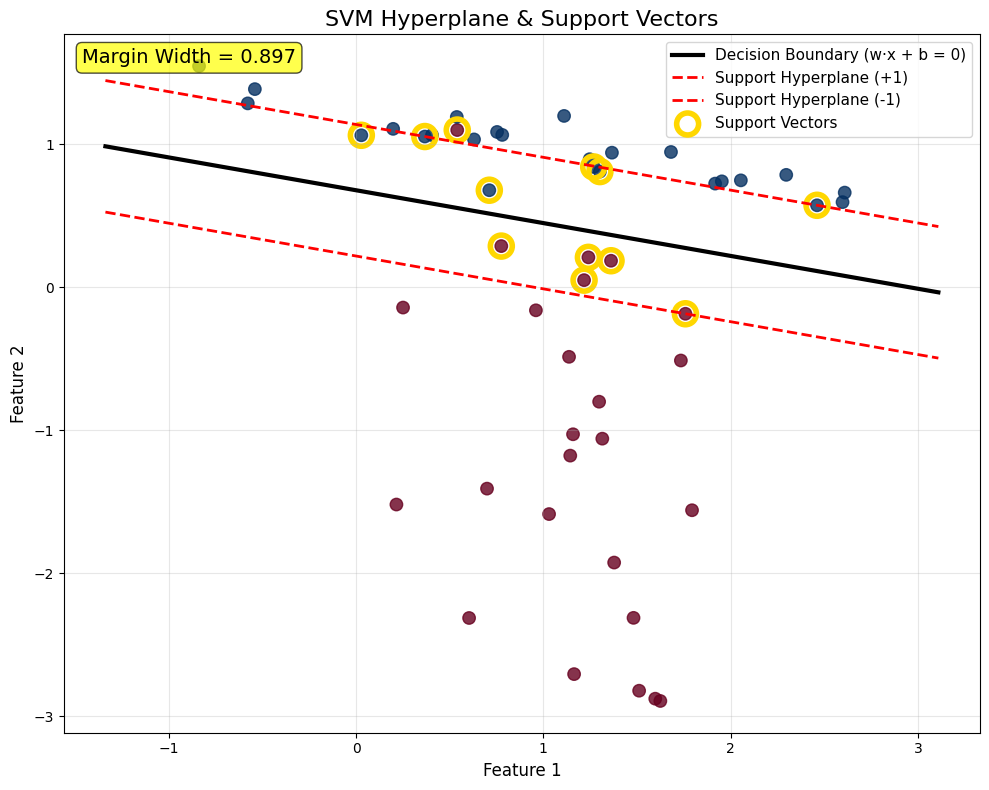


Support Vectors indices: [ 1  2  6  8 33 41 12 15 20 23 29 46]
Margin width: 0.897


In [19]:
print("BLOCK 1: SVM HYPERPLANE GEOMETRY")
print("="*40)

# Generate separable 2D data
X_geo, y_geo = make_classification(n_samples=50, n_features=2, n_redundant=0,
                                  n_clusters_per_class=1, random_state=42)
svm_geo = SVC(kernel='linear').fit(X_geo, y_geo)

# Create plot
plt.figure(figsize=(10, 8))
plt.scatter(X_geo[:, 0], X_geo[:, 1], c=y_geo, cmap='RdBu', s=80, alpha=0.8)
plt.title('SVM Hyperplane & Support Vectors', fontsize=16)

# Define plot range
plot_range = np.linspace(X_geo[:, 0].min()-0.5, X_geo[:, 0].max()+0.5, 100)

# SVM parameters
w = svm_geo.coef_[0]
b = svm_geo.intercept_[0]

# Plot decision boundary and margins
plt.plot(plot_range, (-w[0] * plot_range - b) / w[1], 'k-', linewidth=3,
         label='Decision Boundary (w·x + b = 0)')
plt.plot(plot_range, (-w[0] * plot_range - b + 1) / w[1], 'r--', linewidth=2,
         label='Support Hyperplane (+1)')
plt.plot(plot_range, (-w[0] * plot_range - b - 1) / w[1], 'r--', linewidth=2,
         label='Support Hyperplane (-1)')

# Highlight support vectors
sv_idx = svm_geo.support_
plt.scatter(X_geo[sv_idx, 0], X_geo[sv_idx, 1], s=250, facecolors='none',
           edgecolors='gold', linewidth=4, label='Support Vectors')

# Margin width
margin = 2 / np.sqrt(np.sum(w ** 2))
plt.text(0.02, 0.98, f'Margin Width = {margin:.3f}', transform=plt.gca().transAxes,
         fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
         verticalalignment='top')

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_hyperplane.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSupport Vectors indices: {sv_idx}")
print(f"Margin width: {margin:.3f}")

BLOCK 2: MARGIN MAXIMIZATION vs OVERFITTING


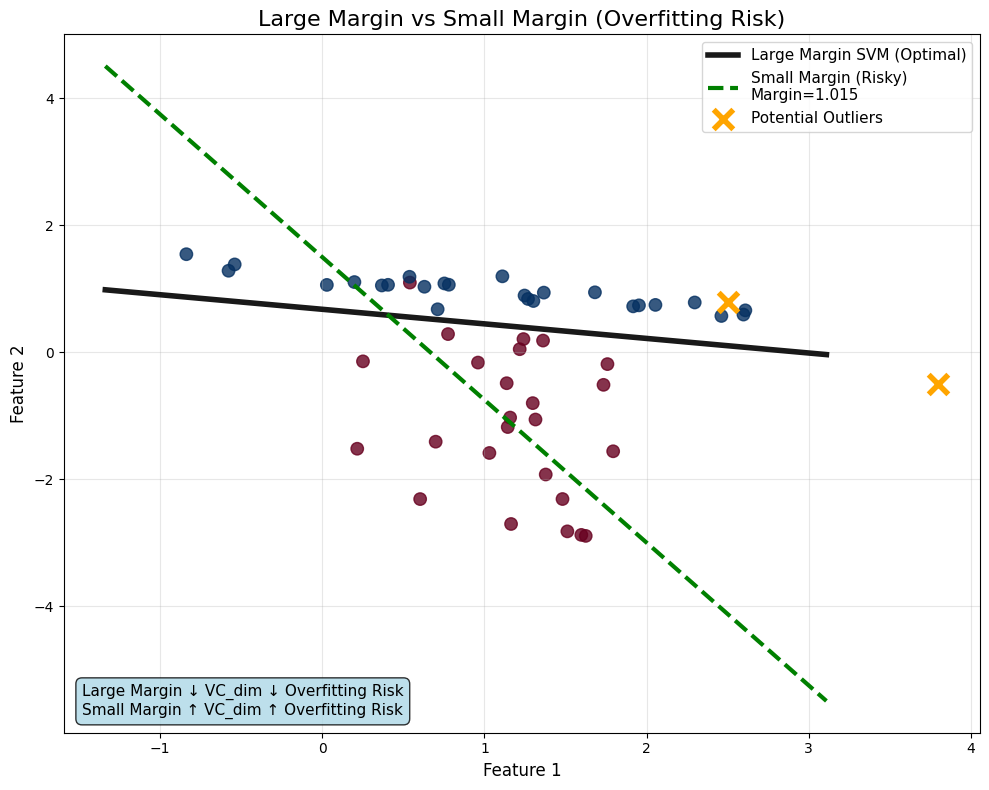


VC DIMENSION EXPLANATION:
• Large margin: Lower model complexity → lower VC dimension
• Small margin: Higher complexity → higher VC dimension
• VC theory: R_expected ≤ R_empirical + √[VC(log N)/N]
• Maximizing margin minimizes VC → better generalization!


In [20]:
print("BLOCK 2: MARGIN MAXIMIZATION vs OVERFITTING")
print("="*45)

# Same data
plt.figure(figsize=(10, 8))
plt.scatter(X_geo[:, 0], X_geo[:, 1], c=y_geo, cmap='RdBu', s=80, alpha=0.8)
plt.title('Large Margin vs Small Margin (Overfitting Risk)', fontsize=16)

# Large margin (optimal SVM)
plt.plot(plot_range, (-w[0] * plot_range - b) / w[1], 'k-', linewidth=4,
         label='Large Margin SVM (Optimal)', alpha=0.9)

# Small margin (risky - prone to overfitting)
w_small = np.array([1.8, 0.8])  # Steeper slope
b_small = -1.2
margin_small = 2 / np.sqrt(np.sum(w_small ** 2))
plt.plot(plot_range, (-w_small[0] * plot_range - b_small) / w_small[1],
         'g--', linewidth=3, label=f'Small Margin (Risky)\nMargin={margin_small:.3f}')

# Add noise points to show overfitting risk
noise_x = np.array([2.5, 3.8])
noise_y = np.array([0.8, -0.5])
plt.scatter(noise_x, noise_y, marker='x', s=200, c='orange', linewidth=4,
           label='Potential Outliers')

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

# VC Dimension annotation
plt.text(0.02, 0.02, 'Large Margin ↓ VC_dim ↓ Overfitting Risk\n'
                   'Small Margin ↑ VC_dim ↑ Overfitting Risk',
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8),
         verticalalignment='bottom')

plt.tight_layout()
plt.savefig('svm_margin_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVC DIMENSION EXPLANATION:")
print("• Large margin: Lower model complexity → lower VC dimension")
print("• Small margin: Higher complexity → higher VC dimension")
print("• VC theory: R_expected ≤ R_empirical + √[VC(log N)/N]")
print("• Maximizing margin minimizes VC → better generalization!")